# Part-A
I(x)<=Mg(x)<br>
M=max(I(x)/g(x))<br>
so,M=2*L<br><br>
sample x~uniform(-L,L)<br>
sample u~uniform(0,1)<br>
accept x if u<=I(x)/(Mg(x))=I(x)    (since Mg(x)=1)<br>



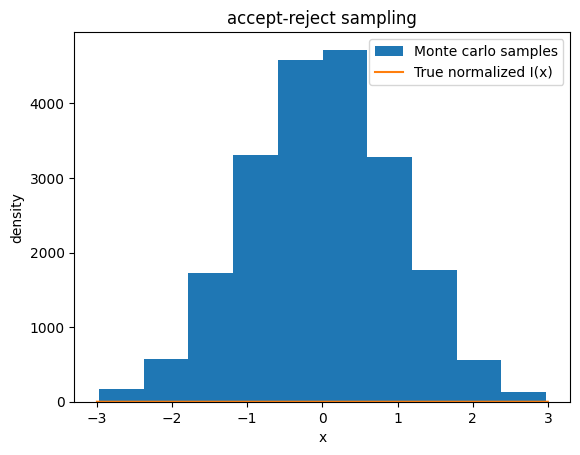

In [5]:
import numpy as np
import matplotlib.pyplot as plt
L=3.0
sigma=1.0
N=50000
M=2*L
def I(x):
    return np.exp(-x**2/(2*sigma**2))
accepted=[]
for i in range(N):
    x=np.random.uniform(-L,L)
    u=np.random.uniform(0,1)
    if u<=I(x):
        accepted.append(x)
accepted=np.array(accepted)
acceptance_rate=len(accepted)/N
xs=np.linspace(-L,L,400)
plt.hist(accepted,label="Monte carlo samples")
plt.plot(xs,I(xs)/np.trapz(I(xs),xs),label="True normalized I(x)")
plt.xlabel("x")
plt.ylabel("density")
plt.title("accept-reject sampling")
plt.legend()

In [9]:
#part B
s_est=M*acceptance_rate
print("estimated S:",s_est)
from math import erf,sqrt,pi
s_ext=sqrt((2*pi))*sigma*erf(L/(sqrt(2)*sigma))
print("exact s:",s_ext)

estimated S: 2.5008
exact s: 2.4998608894830947


In [12]:
#part c
x2_mean=np.mean(accepted**2)
print("<x^2> :",x2_mean)
"""if the proposal distribution is close to the signal shape,more samples are accepted and the method
is efficient.otherwise many samples are rejeced.accept-reject sampling doesnt need the
exact integral because the no of accepted points automatically gives teh correct scaling"""

<x^2> : 0.9785314700981272


'if the proposal distribution is close to the signal shape,more samples are accepted and the method\nis efficient.otherwise many samples are rejeced.accept-reject sampling doesnt need the\nexact integral because the no of accepted points automatically gives teh correct scaling'

### Q2

In [15]:
import numpy as np
import matplotlib.pyplot as plt
P=np.array([
    [0.85,0.10,0.05],
    [0.15,0.75,0.10],
    [0.30,0.20,0.50]

])

In [16]:
#part A
eigval,eigvec=np.linalg.eig(P.T)
id=np.argmin(np.abs(eigval-1))
pi_stat=np.real(eigvec[:,id])
pi_stat=pi_stat/np.sum(pi_stat)
print("stationary distrubution :")
print(f"A={pi_stat[0]:.4f},B={pi_stat[1]:.4f},C={pi_stat[2]:.4f}")

stationary distrubution :
A=0.5600,B=0.3200,C=0.1200


the lowest energy state doesnot have probability 1 becuase thermal fluctuations
allow the system to move to higher-energy states.the transition probabilites control
how easily the system leaves or enter each state,which determines the final balance of probabilites

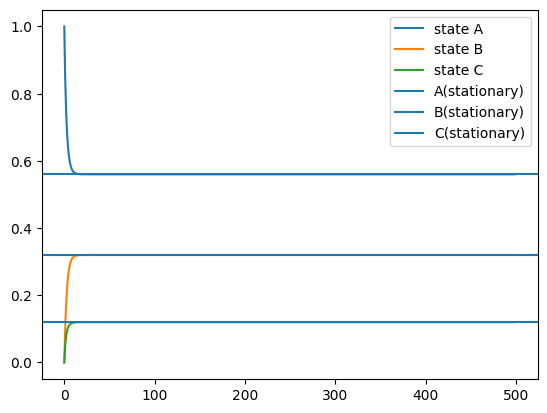

In [18]:
#part B
T=500
pi=np.zeros((T,3))
pi[0]=np.array([1,0,0])
for t in range(T-1):
    pi[t+1]=pi[t]@P
plt.plot(pi[:,0],label="state A")
plt.plot(pi[:,1],label="state B")
plt.plot(pi[:,2],label="state C")
plt.axhline(pi_stat[0],label="A(stationary)")   
plt.axhline(pi_stat[1],label="B(stationary)")  
plt.axhline(pi_stat[2],label="C(stationary)")  
plt.legend() 

the system reaches equilibrium quickly because the transition matrix has large self-transition probs and strong mmixing btw states.state B equilibruim fastest since it has balnced incoming and outgoing probs,while state C euilibrates slightly slower due to lower transition probs into it

# Q3

C:\Users\Abhinav Shivanadri\AppData\Local\Temp\ipykernel_21132\123823536.py:7: RuntimeWarning: invalid value encountered in divide
  return (f**2)/(np.exp(f/T)-1)


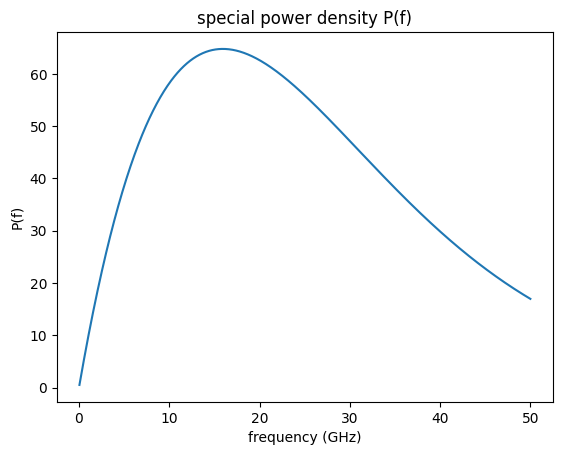

In [20]:
import numpy as np
import matplotlib.pyplot as plt
T=10.0
f_min,f_max=0.0,50.0
N=50000
def P(f):
    return (f**2)/(np.exp(f/T)-1)

f_plot=np.linspace(f_min,f_max,1000)
P_plot=P(f_plot)
plt.plot(f_plot,P_plot)
plt.xlabel("frequency (GHz)")  
plt.ylabel("P(f)")
plt.title("special power density P(f)")  
plt.show()

the integrand increases at low freguencies and decays exponentially at high frquencies,so a truncated exponential captures the tail behaviour well.it places more samples in regions where the integrand contributes significantly to the integral.this reduces wasted samples compared to uniform sampling.sampling from the distibution is easy using inverse transform sampling

In [21]:
f_naive=np.random.uniform(f_min,f_max,N)
X_naive=P(f_naive)*(f_max-f_min)
phi_naive=np.mean(X_naive)
var_naive=np.var(X_naive)
print("Naive MOnte carlo:")
print("Phi_naive=",phi_naive)
print("Variance_naive=",var_naive)
lam=0.12
u=np.random.rand(N)
Z=1-np.exp(-lam*f_max)
f_is=-np.log(1-u*Z)/lam
def q_pdf(f):
    return lam*np.exp(-lam*f)/Z
X_is=P(f_is)/q_pdf(f_is)
phi_is=np.mean(X_is)
var_is=np.var(X_is)
print("important sampling:")
print("phi_is=",phi_is)
print("variance_is=",var_is)    

Naive MOnte carlo:
Phi_naive= 2157.122410692275
Variance_naive= 693791.9939637783
important sampling:
phi_is= 2132.2173798626827
variance_is= 19588536.055870675


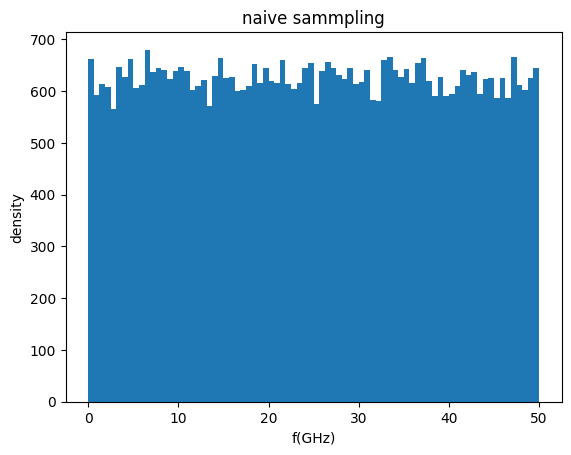

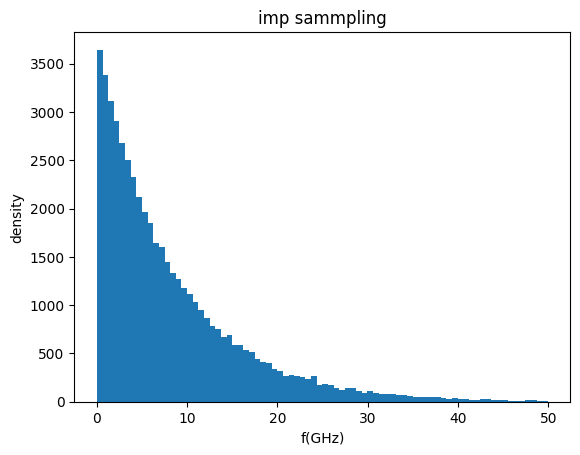

In [23]:
plt.hist(f_naive,bins=80)
plt.title("naive sammpling")
plt.xlabel("f(GHz)")
plt.ylabel("density")
plt.show()
plt.hist(f_is,bins=80)
plt.title("imp sammpling")
plt.xlabel("f(GHz)")
plt.ylabel("density")
plt.show()

### part C
the naive method wastes any samples in regions where the spectral power is almost zero,contributing little to the integral.Importance sampling concetrates samples in regions where teh integrand is large,improving effieciency.the closer the proposak distribution matches the shape of the integrand,the lower the varaince of the estimate